In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob

In [2]:
batch_sizes = (32, 64, 128)
modes = ('onfly', 'preload')
mode_label = {"onfly": "on-the-fly",
              "preload": "before training"}

# graphing stuff
colours = {32: "tab:blue", 64: "tab:orange", 128: "tab:green"}
linestyle = {"onfly": "solid", "preload": "solid"}
colours = {("onfly", 32): "tab:blue", ("onfly", 64): "tab:orange", ("onfly", 128): "tab:green",
           ("preload", 32): "skyblue", ("preload", 64): "peachpuff", ("preload", 128): "lightgreen"}

In [3]:
data_dir_fwd = os.path.join(os.getcwd(), 'final_data_analysis', 'resource_data', 'forward')
data_dir_bkwd = os.path.join(os.getcwd(), 'final_data_analysis', 'resource_data', 'backward')
plot_dir = os.path.join(os.getcwd(), 'final_plots', 'resource')

In [4]:
data_files_fwd = glob.glob(os.path.join(data_dir_fwd, "*.csv"))
data_files_bkwd = glob.glob(os.path.join(data_dir_bkwd, "*.csv"))

In [5]:
print(f"Number of forward resource files: {len(data_files_fwd)}")
print(f"Number of backward resource files: {len(data_files_bkwd)}")

Number of forward resource files: 18
Number of backward resource files: 18


In [6]:
def get_params_from_filename(file):
    """
    Inputs:
        file: str, full file path
    Outputs:
        batch_size: int
        num_workers: int
        num_samples: int
        repeat: int
    """
    file_name = os.path.basename(file)
    
    batch_size = int(file_name.split("_batch-")[1].split("_work-")[0])
    num_workers = int(file_name.split("_work-")[1].split("_samples-")[0])
    num_samples = int(file_name.split("_samples-")[1].split("_repeat-")[0])
    repeat = int(file_name.split("_repeat-")[1].split("_labels-")[0])
    total_samples = num_samples * repeat
    mode = file_name.split(".csv")[0].split("_")[-1]

    return batch_size, num_workers, total_samples, mode

Combine files with same batch size and mode in averaged dataframe

In [7]:
data_dict_fwd = {} # (mode, batch size): concatenated df with all info about all runs
data_dict_bkwd = {} # (mode, batch size): concatenated df with all info about all runs

for i, data_files in enumerate([data_files_fwd, data_files_bkwd]):
    # set the correct dictionary for data storage
    if i == 0:
        data_dict = data_dict_fwd
    else:
        data_dict = data_dict_bkwd

    for file in data_files:
        batch_size, num_workers, total_samples, mode = get_params_from_filename(file)
        df = pd.read_csv(file)

        # remove first and last datapoint
        df = df.iloc[1:-1]
        
        if (mode, batch_size) not in data_dict:
            data_dict[(mode, batch_size)] = df

        else:
            # concatenate data to end of df
            data_dict[(mode, batch_size)] = pd.concat([data_dict[(mode, batch_size)], df])

In [8]:
# get the average per iteration across runs
for i, data_files in enumerate([data_files_fwd, data_files_bkwd]):
    # set the correct dictionary for data storage
    if i == 0:
        data_dict = data_dict_fwd
    else:
        data_dict = data_dict_bkwd
        
    for (mode, batch_size) in data_dict:
        data_dict[(mode, batch_size)] = data_dict[(mode, batch_size)].groupby(level=0).mean()

GPU utilization for forward and backwards phase

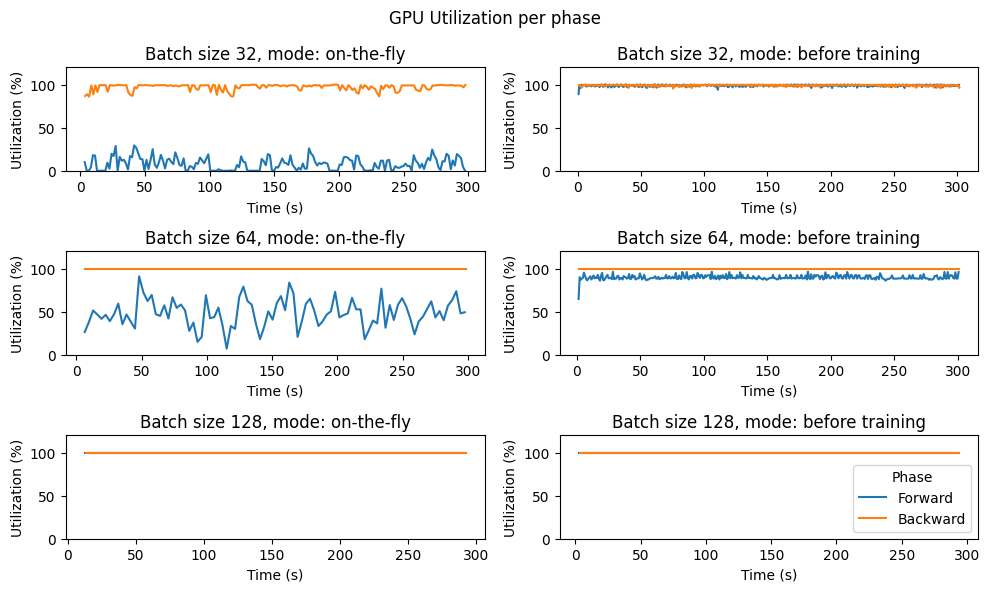

In [9]:
fig, ax = plt.subplots(3, 2, figsize=(10, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for j, m in enumerate(modes):
        data_fwd = data_dict_fwd[(m, b)]
        data_bkwd = data_dict_bkwd[(m, b)]

        # average utilization
        fwd_avg = data_fwd["GPU utilization"].mean()
        bkwd_avg = data_bkwd["GPU utilization"].mean()

        ax[i, j].plot(data_fwd["timestamp"]/1e9 ,data_fwd["GPU utilization"], label=f"Forward", color="tab:blue")
        ax[i, j].plot(data_bkwd["timestamp"]/1e9 ,data_bkwd["GPU utilization"], label=f"Backward", color="tab:orange")
        
        ax[i, j].set_title(f"Batch size {b}, mode: {mode_label[m]}")
        ax[i, j].set_xlabel("Time (s)")
        ax[i, j].set_ylabel("Utilization (%)")
        ax[i, j].set_ylim(0, 120)

ax[i, j].legend(loc="lower right", title="Phase")
fig.suptitle("GPU Utilization per phase")
fig.savefig(os.path.join(plot_dir, "gpu_util_phase"),  dpi=300, bbox_inches="tight")

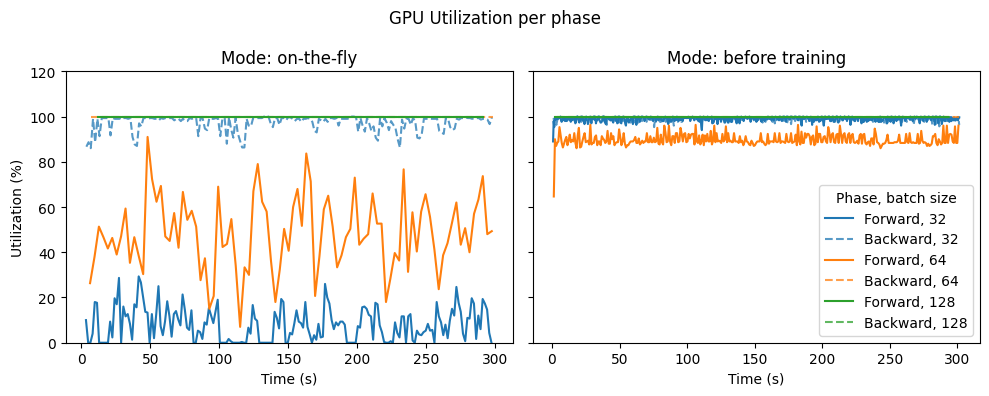

In [10]:
# styles
colours_fwd = {32: "tab:blue", 64: "tab:orange", 128: "tab:green"}
colours_bkwd = {32: "darkorange", 64: "orange", 128: "navajowhite"}

linestyles = {"onfly": "solid", "preload": "dashed"}

fig, ax = plt.subplots(1, 2, figsize=(10, 4), layout="tight", sharey=True)

for i, b in enumerate(batch_sizes):
    for j, m in enumerate(modes):
        data_fwd = data_dict_fwd[(m, b)]
        data_bkwd = data_dict_bkwd[(m, b)]

        # average utilization
        fwd_avg = data_fwd["GPU utilization"].mean()
        bkwd_avg = data_bkwd["GPU utilization"].mean()

        ax[j].plot(data_fwd["timestamp"]/1e9 ,data_fwd["GPU utilization"], label=f"Forward, {b}", color=colours_fwd[b])
        ax[j].plot(data_bkwd["timestamp"]/1e9 ,data_bkwd["GPU utilization"], label=f"Backward, {b}", color=colours_fwd[b], alpha=0.75, linestyle="dashed")

        ax[j].set_title(f"Mode: {mode_label[m]}")
        ax[j].set_xlabel("Time (s)")
        ax[j].set_ylim(0, 120)

ax[j].legend(loc="lower right", title="Phase, batch size")
ax[0].set_ylabel("Utilization (%)")
fig.suptitle("GPU Utilization per phase")
fig.savefig(os.path.join(plot_dir, "gpu_util_phase2"),  dpi=300, bbox_inches="tight")

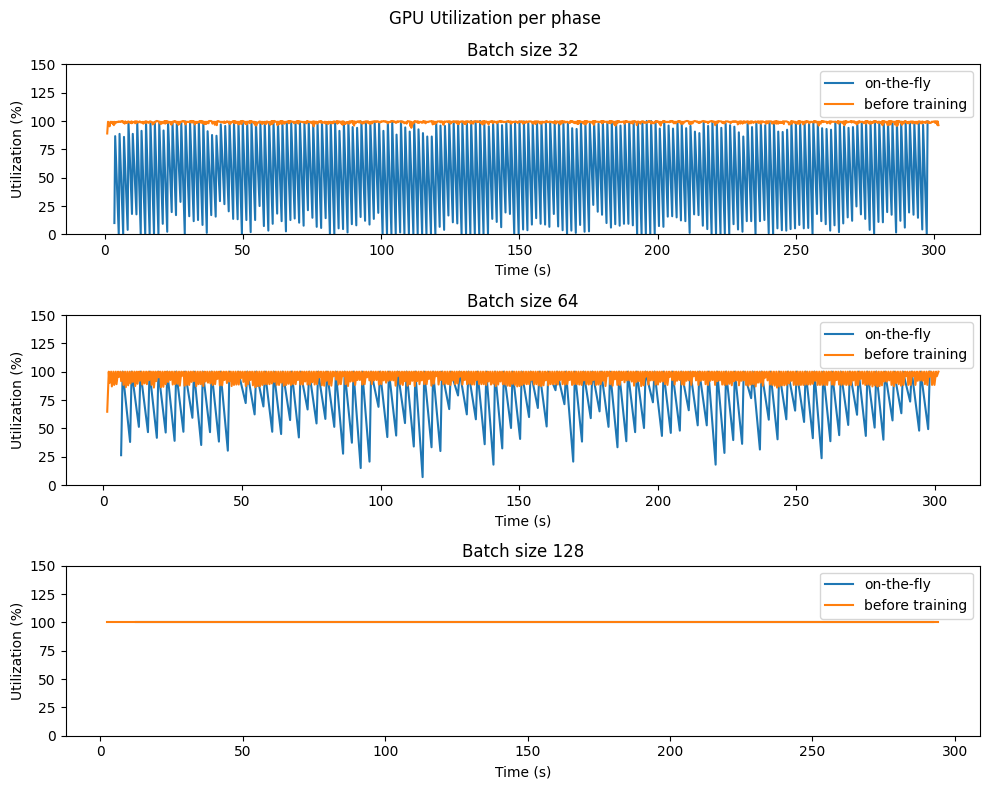

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), layout="tight")

for i, b in enumerate(batch_sizes):
    for j, m in enumerate(modes):
        data_fwd = data_dict_fwd[(m, b)]
        data_bkwd = data_dict_bkwd[(m, b)]

        data = pd.concat([data_fwd, data_bkwd])
        data = data.sort_values(by='timestamp')

        ax[i].plot(data["timestamp"]/1e9 ,data["GPU utilization"], label=f"{mode_label[m]}")
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("Utilization (%)")
        ax[i].legend(loc="upper right")
        ax[i].set_ylim(0, 150)

fig.suptitle("GPU Utilization per phase")
fig.savefig(os.path.join(plot_dir, "gpu_util_phase_consecutive"),  dpi=300, bbox_inches="tight")

CPU utilization

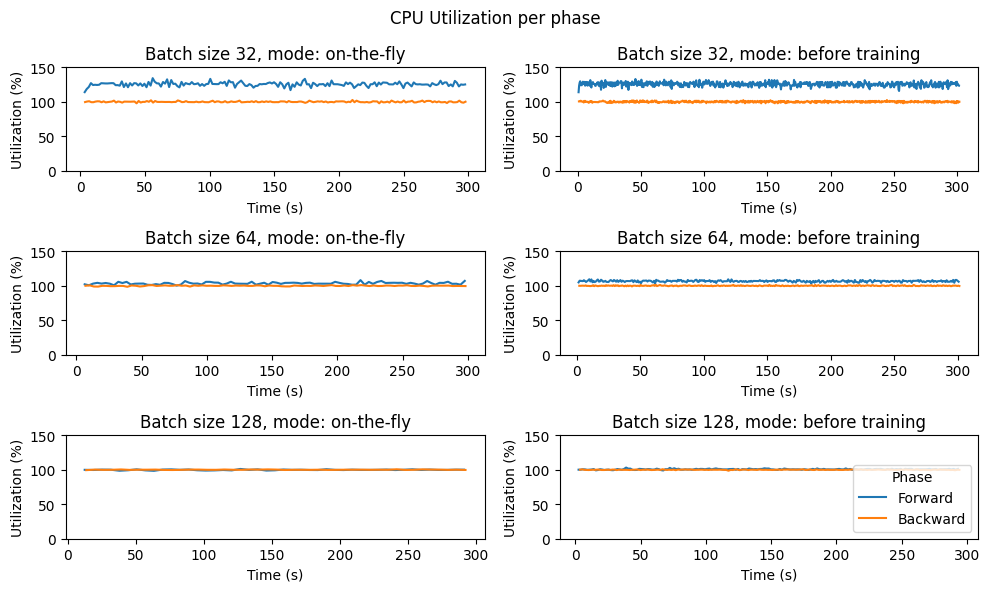

In [12]:
fig, ax = plt.subplots(3, 2, figsize=(10, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for j, m in enumerate(modes):
        data_fwd = data_dict_fwd[(m, b)]
        data_bkwd = data_dict_bkwd[(m, b)]

        # average utilization
        fwd_avg = data_fwd["CPU utilization"].mean()
        bkwd_avg = data_bkwd["CPU utilization"].mean()

        ax[i, j].plot(data_fwd["timestamp"]/1e9 ,data_fwd["CPU utilization"], label=f"Forward", color="tab:blue")
        ax[i, j].plot(data_bkwd["timestamp"]/1e9 ,data_bkwd["CPU utilization"], label=f"Backward", color="tab:orange")

        ax[i, j].set_title(f"Batch size {b}, mode: {mode_label[m]}")
        ax[i, j].set_xlabel("Time (s)")
        ax[i, j].set_ylabel("Utilization (%)")
        ax[i, j].set_ylim(0, 150)

ax[i, j].legend(loc="lower right", title="Phase")
fig.suptitle("CPU Utilization per phase")
fig.savefig(os.path.join(plot_dir, "cpu_util_phase"),  dpi=300, bbox_inches="tight")

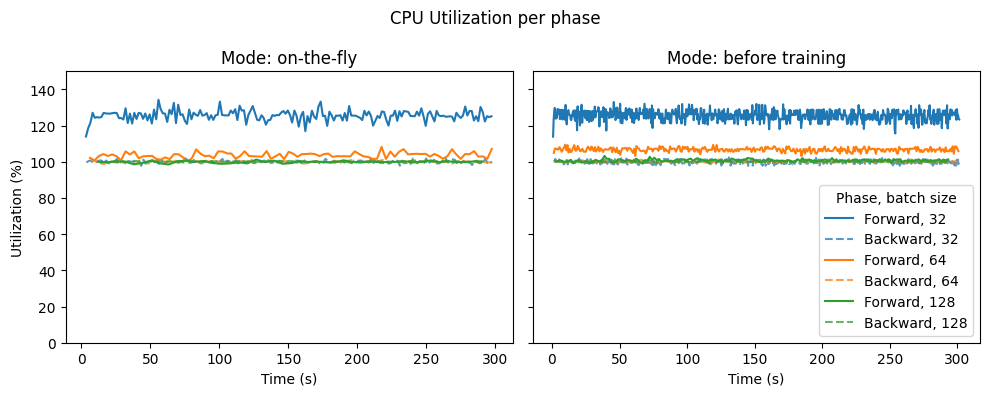

In [13]:
# styles
colours_fwd = {32: "tab:blue", 64: "tab:orange", 128: "tab:green"}

linestyles = {"onfly": "solid", "preload": "dashed"}

fig, ax = plt.subplots(1, 2, figsize=(10, 4), layout="tight", sharey=True)

for i, b in enumerate(batch_sizes):
    for j, m in enumerate(modes):
        data_fwd = data_dict_fwd[(m, b)]
        data_bkwd = data_dict_bkwd[(m, b)]

        # average utilization
        fwd_avg = data_fwd["CPU utilization"].mean()
        bkwd_avg = data_bkwd["CPU utilization"].mean()

        ax[j].plot(data_fwd["timestamp"]/1e9 ,data_fwd["CPU utilization"], label=f"Forward, {b}", color=colours_fwd[b])
        ax[j].plot(data_bkwd["timestamp"]/1e9 ,data_bkwd["CPU utilization"], label=f"Backward, {b}", color=colours_fwd[b], alpha=0.75, linestyle="dashed")

        ax[j].set_title(f"Mode: {mode_label[m]}")
        ax[j].set_xlabel("Time (s)")
        ax[j].set_ylim(0, 150)

ax[j].legend(loc="lower right", title="Phase, batch size")
ax[0].set_ylabel("Utilization (%)")
fig.suptitle("CPU Utilization per phase")
fig.savefig(os.path.join(plot_dir, "cpu_util_phase2"),  dpi=300, bbox_inches="tight")

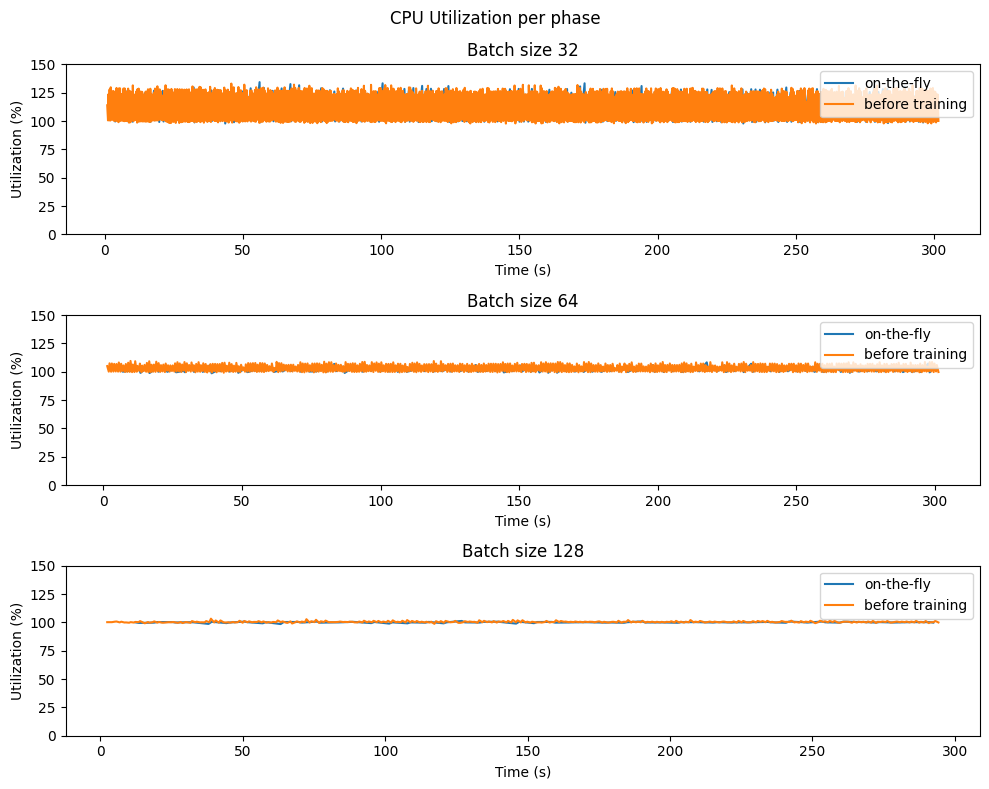

In [14]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), layout="tight")

for i, b in enumerate(batch_sizes):
    for j, m in enumerate(modes):
        data_fwd = data_dict_fwd[(m, b)]
        data_bkwd = data_dict_bkwd[(m, b)]

        data = pd.concat([data_fwd, data_bkwd])
        data = data.sort_values(by='timestamp')

        ax[i].plot(data["timestamp"]/1e9 ,data["CPU utilization"], label=f"{mode_label[m]}")
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("Utilization (%)")
        ax[i].legend(loc="upper right")
        ax[i].set_ylim(0, 150)

fig.suptitle("CPU Utilization per phase")
fig.savefig(os.path.join(plot_dir, "cpu_util_phase_consecutive"),  dpi=300, bbox_inches="tight")

GPU memory

Text(0.5, 0.98, 'GPU Memory Utilization per phase')

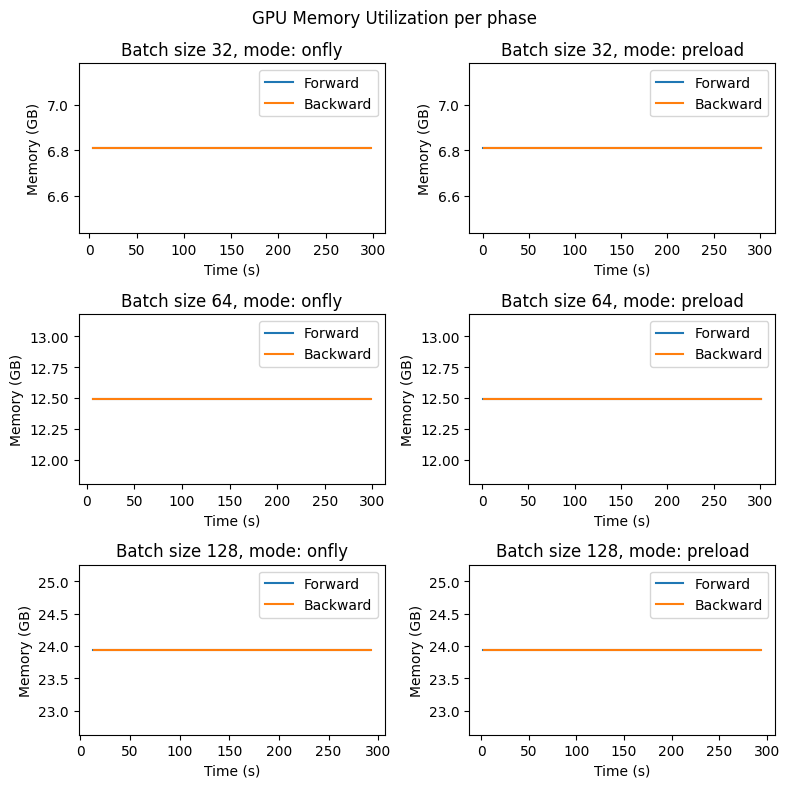

In [15]:
fig, ax = plt.subplots(3, 2, figsize=(8, 8), layout="tight")

for i, b in enumerate(batch_sizes):
    for j, m in enumerate(modes):
        data_fwd = data_dict_fwd[(m, b)]
        data_bkwd = data_dict_bkwd[(m, b)]

        ax[i, j].plot(data_fwd["timestamp"]/1e9 ,data_fwd["GPU memory"]/1e9, label="Forward", color="tab:blue")
        ax[i, j].plot(data_bkwd["timestamp"]/1e9 ,data_bkwd["GPU memory"]/1e9, label="Backward", color="tab:orange")
        ax[i, j].set_title(f"Batch size {b}, mode: {m}")
        ax[i, j].set_xlabel("Time (s)")
        ax[i, j].set_ylabel("Memory (GB)")
        ax[i, j].legend()

fig.suptitle("GPU Memory Utilization per phase")